In [16]:
import os
import numpy as np
import pandas as pd
import warnings
import pydeck as pdk
import plotly as py
import plotly.express as px
import mlxtend

In [17]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
RANDOM_STATE = 42

Phase 1: Read Data and display

In [3]:
TRAIN_PATH = "train.csv" 
TEST_PATH  = "test.csv"
train = pd.read_csv(TRAIN_PATH, nrows= 2000000)
test  = pd.read_csv(TEST_PATH)

train.shape, test.shape, train.head()

((2000000, 8),
 (9914, 7),
                              key  fare_amount          pickup_datetime  pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count
 0    2009-06-15 17:26:21.0000001          4.5  2009-06-15 17:26:21 UTC        -73.844311        40.721319         -73.841610         40.712278                1
 1    2010-01-05 16:52:16.0000002         16.9  2010-01-05 16:52:16 UTC        -74.016048        40.711303         -73.979268         40.782004                1
 2   2011-08-18 00:35:00.00000049          5.7  2011-08-18 00:35:00 UTC        -73.982738        40.761270         -73.991242         40.750562                2
 3    2012-04-21 04:30:42.0000001          7.7  2012-04-21 04:30:42 UTC        -73.987130        40.733143         -73.991567         40.758092                1
 4  2010-03-09 07:51:00.000000135          5.3  2010-03-09 07:51:00 UTC        -73.968095        40.768008         -73.956655         40.783762                1)

In [4]:
def quick_eda(df, name="DataFrame"):
    print(f"--- Quick EDA for {name} ---")
    print("DataFrame shape:", df.shape)
    print("\nDataFrame info:")
    print(df.info())
    print("\nDataFrame description:")
    print(df.describe())
    print("\nMissing values:")
    print(df.isnull().sum())
    summary = {
        "rows": df.shape[0],
        "cols": df.shape[1],
        "memory_gb_est": df.memory_usage(deep=True).sum() / 1e9
    }
    return summary
quick_train = quick_eda(train, "Train Data")
quick_test = quick_eda(test, "Test Data")
quick_train, quick_test

--- Quick EDA for Train Data ---
DataFrame shape: (2000000, 8)

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   key                str    
 1   fare_amount        float64
 2   pickup_datetime    str    
 3   pickup_longitude   float64
 4   pickup_latitude    float64
 5   dropoff_longitude  float64
 6   dropoff_latitude   float64
 7   passenger_count    int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 122.1 MB
None

DataFrame description:
        fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count
count  2.000000e+06      2.000000e+06     2.000000e+06       1.999986e+06      1.999986e+06     2.000000e+06
mean   1.134779e+01     -7.252321e+01     3.992963e+01      -7.252395e+01      3.992808e+01     1.684113e+00
std    9.852883e+00      1.286804e+01     7.983352e+00       1.277497e+01      1.03

({'rows': 2000000, 'cols': 8, 'memory_gb_est': np.float64(0.393356327)},
 {'rows': 9914, 'cols': 7, 'memory_gb_est': np.float64(0.001870143)})

In [ ]:
def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

def manhattan_km(lon1, lat1, lon2, lat2):
    """
    Approximate road-like Manhattan distance on lat/lon:
    north-south leg + east-west leg
    """
    leg1 = haversine_km(lon1, lat1, lon1, lat2)  # move only in latitude
    leg2 = haversine_km(lon1, lat2, lon2, lat2)  # move only in longitude
    return leg1 + leg2

def trip_bearing(lon1, lat1, lon2, lat2):
    """
    Initial bearing (forward azimuth) from pickup to dropoff in degrees.
    Output range: [-180, 180]
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1

    x = np.sin(dlon) * np.cos(lat2)
    y = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    )

    bearing = np.degrees(np.arctan2(x, y))
    return bearing

# Define coordinates for points of interest (POIs) in NYC
POI_COORDS = {
    "jfk": (-73.7781, 40.6413),
    "lga": (-73.8740, 40.7769),
    "manhattan_center": (-73.9855, 40.7580),
}

def distance_to_poi(lon, lat, poi_lon, poi_lat):
    return haversine_km(lon, lat, poi_lon, poi_lat)

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # datetime
    out["pickup_datetime"] = pd.to_datetime(out["pickup_datetime"], errors="coerce", utc=True)
    out["pickup_hour"] = out["pickup_datetime"].dt.hour
    out["pickup_dow"] = out["pickup_datetime"].dt.dayofweek  # Mon=0
    out["pickup_month"] = out["pickup_datetime"].dt.month
    out["is_weekend"] = (out["pickup_dow"] >= 5).astype(int)

    # rush hour flags
    out["is_rush_hour"] = out["pickup_hour"].isin([7,8,9,16,17,18,19]).astype(int)
    out["is_night"] = out["pickup_hour"].isin([22,23,0,1,2,3,4,5]).astype(int)

    # distance
    out["haversine_km"] = haversine_km(
        out["pickup_longitude"], out["pickup_latitude"],
        out["dropoff_longitude"], out["dropoff_latitude"]
    )

    out["manhattan_km"] = manhattan_km(
        out["pickup_longitude"], out["pickup_latitude"],
        out["dropoff_longitude"], out["dropoff_latitude"]
    )

    out["distance_ratio_manhattan_haversine"] = (
        out["manhattan_km"] / out["haversine_km"].replace(0, np.nan)
    )

    out["trip_bearing"] = trip_bearing(
        out["pickup_longitude"], out["pickup_latitude"],
        out["dropoff_longitude"], out["dropoff_latitude"]
    )

    bearing_rad = np.radians(out["trip_bearing"])
    out["bearing_sin"] = np.sin(bearing_rad)
    out["bearing_cos"] = np.cos(bearing_rad)

    # POI distance features
    jfk_lon, jfk_lat = POI_COORDS["jfk"]
    lga_lon, lga_lat = POI_COORDS["lga"]
    mh_lon, mh_lat = POI_COORDS["manhattan_center"]

    out["pickup_to_jfk_km"] = distance_to_poi(
        out["pickup_longitude"], out["pickup_latitude"], jfk_lon, jfk_lat
    )
    out["dropoff_to_jfk_km"] = distance_to_poi(
        out["dropoff_longitude"], out["dropoff_latitude"], jfk_lon, jfk_lat
    )

    out["pickup_to_lga_km"] = distance_to_poi(
        out["pickup_longitude"], out["pickup_latitude"], lga_lon, lga_lat
    )
    out["dropoff_to_lga_km"] = distance_to_poi(
        out["dropoff_longitude"], out["dropoff_latitude"], lga_lon, lga_lat
    )

    out["pickup_to_manhattan_km"] = distance_to_poi(
        out["pickup_longitude"], out["pickup_latitude"], mh_lon, mh_lat
    )
    out["dropoff_to_manhattan_km"] = distance_to_poi(
        out["dropoff_longitude"], out["dropoff_latitude"], mh_lon, mh_lat
    )

    # optional airport flags
    airport_radius_km = 2.0

    out["is_jfk_trip"] = (
        (out["pickup_to_jfk_km"] <= airport_radius_km) |
        (out["dropoff_to_jfk_km"] <= airport_radius_km)
    ).astype(int)

    out["is_lga_trip"] = (
        (out["pickup_to_lga_km"] <= airport_radius_km) |
        (out["dropoff_to_lga_km"] <= airport_radius_km)
    ).astype(int)

    out["pickup_in_manhattan_core"] = (
        (out["pickup_longitude"].between(-74.02, -73.93)) &
        (out["pickup_latitude"].between(40.70, 40.82))
    ).astype(int)

    out["dropoff_in_manhattan_core"] = (
        (out["dropoff_longitude"].between(-74.02, -73.93)) &
        (out["dropoff_latitude"].between(40.70, 40.82))
    ).astype(int)

    out["dist_x_jfk"] = out["manhattan_km"] * out["is_jfk_trip"]
    out["dist_x_lga"] = out["manhattan_km"] * out["is_lga_trip"]

    out["is_short_trip"] = (out["manhattan_km"] < 1).astype(int)
    out["is_long_trip"] = (out["manhattan_km"] >= 15).astype(int)
    out["dist_x_long_trip"] = out["manhattan_km"] * out["is_long_trip"]

    out["dist_x_rush"] = out["manhattan_km"] * out["is_rush_hour"]
    out["dist_x_night"] = out["manhattan_km"] * out["is_night"]

    out["hour_sin"] = np.sin(2 * np.pi * out["pickup_hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["pickup_hour"] / 24)

    return out


train_feat = add_features(train)
train_feat.head()


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_dow,pickup_month,is_weekend,is_rush_hour,is_night,haversine_km,manhattan_km,distance_ratio_manhattan_haversine,trip_bearing,bearing_sin,bearing_cos,pickup_to_jfk_km,dropoff_to_jfk_km,pickup_to_lga_km,dropoff_to_lga_km,pickup_to_manhattan_km,dropoff_to_manhattan_km,is_jfk_trip,is_lga_trip,pickup_in_manhattan_core,dropoff_in_manhattan_core,dist_x_jfk,dist_x_lga,is_short_trip,is_long_trip,dist_x_long_trip,dist_x_rush,dist_x_night,hour_sin,hour_cos
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,17,0,6,0,1,0,1.030764,1.232968,1.196169,167.240469,0.220860,-0.975306,10.504346,9.538054,6.667174,7.686289,12.575088,13.146477,0,0,0,0,0.0,0.0,0,0,0.0,1.232968,0.000000,-0.965926,-0.258819
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,16,1,1,0,1,0,8.450134,10.958352,1.296826,21.498365,0.366475,0.930428,21.523172,23.071126,14.014555,8.881723,5.795393,2.720228,0,0,1,1,0.0,0.0,0,0,0.0,10.958352,0.000000,-0.866025,-0.500000
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0,3,8,0,0,1,1.389525,1.907024,1.372428,-148.966789,-0.515535,-0.856869,21.807027,21.690922,9.320644,10.299282,0.431656,0.958107,0,0,1,1,0.0,0.0,0,0,0.0,0.000000,1.907024,0.000000,1.000000
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,4,5,4,1,0,1,2.799270,3.147918,1.124550,-7.672164,-0.133505,0.991048,20.369738,22.192143,10.699370,10.119395,2.767381,0.511109,0,0,1,1,0.0,0.0,0,0,0.0,0.000000,3.147918,0.866025,0.500000
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,7,1,3,0,1,0,1.999157,2.714951,1.358048,28.802783,0.481796,0.876283,21.330886,21.850063,7.985091,7.001167,1.840427,3.755836,0,0,1,1,0.0,0.0,0,0,0.0,2.714951,0.000000,0.965926,-0.258819


In [28]:
NYC_BOUNDS = {
    "lat_min": 40.0, "lat_max": 42.0,
    "lon_min": -75.0, "lon_max": -72.0
}

def cleaning_pipeline(df: pd.DataFrame, is_train: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      cleaned_df
      report_df: rule-wise removal report
    """
    x = df.copy()
    report = []

    def apply_rule(mask_keep: pd.Series, rule_name: str):
        nonlocal x, report
        before = len(x)
        x = x.loc[mask_keep].copy()
        after = len(x)
        report.append({
            "rule": rule_name,
            "removed": before - after,
            "removed_pct": (before - after) / before * 100.0 if before else 0.0,
            "remaining": after
        })

    # 0) drop rows with essential missing
    essential = ["pickup_datetime","pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude","passenger_count"]
    if is_train:
        essential += ["fare_amount"]

    before = len(x)
    x = x.dropna(subset=essential).copy()
    report.append({"rule":"dropna_essential", "removed": before-len(x), "removed_pct": (before-len(x))/before*100.0, "remaining": len(x)})

    # 1) passenger_count plausible
    apply_rule((x["passenger_count"] >= 1) & (x["passenger_count"] <= 6), "passenger_count_1_to_6")

    # 2) geo bounds for pickup/dropoff
    b = NYC_BOUNDS
    geo_keep = (
        x["pickup_latitude"].between(b["lat_min"], b["lat_max"]) &
        x["dropoff_latitude"].between(b["lat_min"], b["lat_max"]) &
        x["pickup_longitude"].between(b["lon_min"], b["lon_max"]) &
        x["dropoff_longitude"].between(b["lon_min"], b["lon_max"])
    )
    apply_rule(geo_keep, "geo_within_nyc_bounds")

    # 3) train-only fare sanity
    if is_train:
        apply_rule(x["fare_amount"] > 0, "fare_amount_positive")
        q_hi = x["fare_amount"].quantile(0.999)
        apply_rule(x["fare_amount"] <= q_hi, f"fare_amount_le_q999({q_hi:.2f})")

    # 4) add features then distance sanity
    x = add_features(x)

    # drop datetime parse failures
    apply_rule(x["pickup_datetime"].notna(), "pickup_datetime_parsed")

    # remove zero/near-zero distance but high fare noise 
    # added manhattan_km > 0 condition to avoid keeping zero-distance outliers with high fare
    apply_rule((x["haversine_km"] > 0) & (x["manhattan_km"] > 0), "distance_gt_0")

    # trim extreme distance
    d_hi = x["haversine_km"].quantile(0.999)
    apply_rule(x["haversine_km"] <= d_hi, f"distance_le_q999({d_hi:.2f}km)")

    report_df = pd.DataFrame(report)
    return x, report_df

train_clean, train_report = cleaning_pipeline(train, is_train=True)
test_clean, _ = cleaning_pipeline(test, is_train=False)

train_clean.shape, test_clean.shape, train_report

((1926679, 39),
 (9819, 38),
                          rule  removed  removed_pct  remaining
 0            dropna_essential       14     0.000700    1999986
 1      passenger_count_1_to_6     7111     0.355552    1992875
 2       geo_within_nyc_bounds    41515     2.083171    1951360
 3        fare_amount_positive      113     0.005791    1951247
 4  fare_amount_le_q999(79.50)     1944     0.099629    1949303
 5      pickup_datetime_parsed        0     0.000000    1949303
 6               distance_gt_0    20695     1.061662    1928608
 7   distance_le_q999(23.26km)     1929     0.100020    1926679)

In [8]:
train_clean.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_dow,pickup_month,is_weekend,is_rush_hour,is_night,haversine_km,manhattan_km,distance_ratio_manhattan_haversine,trip_bearing,bearing_sin,bearing_cos,pickup_to_jfk_km,dropoff_to_jfk_km,pickup_to_lga_km,dropoff_to_lga_km,pickup_to_manhattan_km,dropoff_to_manhattan_km,is_jfk_trip,is_lga_trip,pickup_in_manhattan_core,dropoff_in_manhattan_core,dist_x_jfk,dist_x_lga,is_short_trip,is_long_trip,dist_x_long_trip,dist_x_rush,dist_x_night,hour_sin,hour_cos
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,17,0,6,0,1,0,1.030764,1.232968,1.196169,167.240469,0.220860,-0.975306,10.504346,9.538054,6.667174,7.686289,12.575088,13.146477,0,0,0,0,0.0,0.0,0,0,0.0,1.232968,0.000000,-0.965926,-0.258819
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,16,1,1,0,1,0,8.450134,10.958352,1.296826,21.498365,0.366475,0.930428,21.523172,23.071126,14.014555,8.881723,5.795393,2.720228,0,0,1,1,0.0,0.0,0,0,0.0,10.958352,0.000000,-0.866025,-0.500000
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0,3,8,0,0,1,1.389525,1.907024,1.372428,-148.966789,-0.515535,-0.856869,21.807027,21.690922,9.320644,10.299282,0.431656,0.958107,0,0,1,1,0.0,0.0,0,0,0.0,0.000000,1.907024,0.000000,1.000000
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,4,5,4,1,0,1,2.799270,3.147918,1.124550,-7.672164,-0.133505,0.991048,20.369738,22.192143,10.699370,10.119395,2.767381,0.511109,0,0,1,1,0.0,0.0,0,0,0.0,0.000000,3.147918,0.866025,0.500000
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,7,1,3,0,1,0,1.999157,2.714951,1.358048,28.802783,0.481796,0.876283,21.330886,21.850063,7.985091,7.001167,1.840427,3.755836,0,0,1,1,0.0,0.0,0,0,0.0,2.714951,0.000000,0.965926,-0.258819


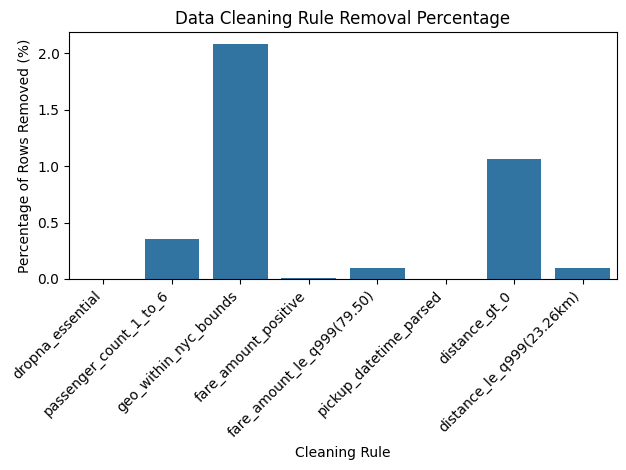

In [12]:
sns.barplot(data=train_report, x="rule", y="removed_pct")
plt.xticks(rotation=45, ha="right")
plt.title("Data Cleaning Rule Removal Percentage")
plt.ylabel("Percentage of Rows Removed (%)")
plt.xlabel("Cleaning Rule")
plt.tight_layout()
plt.show()

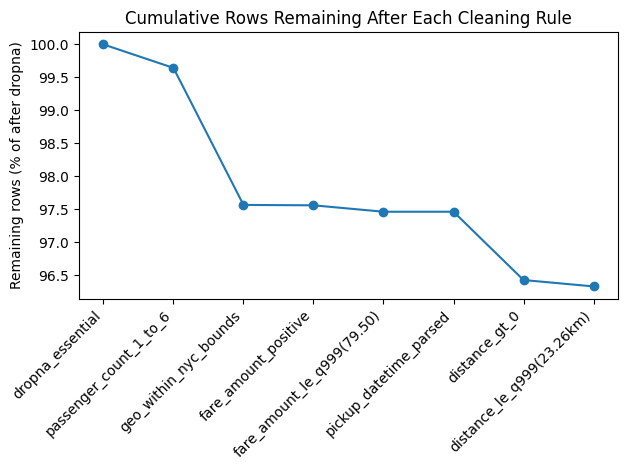

In [13]:
rep = train_report.copy()
rep["remaining_pct_of_start"] = rep["remaining"] / rep["remaining"].iloc[0] * 100

plt.figure()
plt.plot(rep["rule"], rep["remaining_pct_of_start"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Remaining rows (% of after dropna)")
plt.title("Cumulative Rows Remaining After Each Cleaning Rule")
plt.tight_layout()
plt.show()

Phase 2: figures

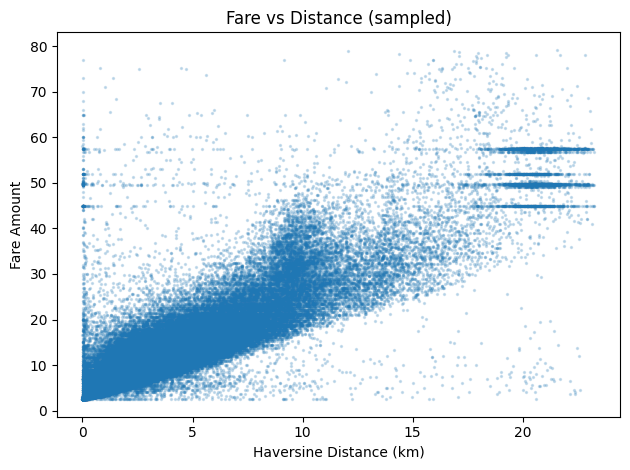

In [14]:
df = train_clean.sample(200_000, random_state=42)
plt.figure()
plt.scatter(df["haversine_km"], df["fare_amount"], s=2, alpha=0.2)
plt.xlabel("Haversine Distance (km)")
plt.ylabel("Fare Amount")
plt.title("Fare vs Distance (sampled)")
plt.tight_layout()
plt.show()

Fare vs Distance(sampled): 强关联，positive，离散水平线，异方差性

Strong and Postive correlation. We can clearly see that when Haversien Distance close to 0km, the fare amount is still stay in a positive interval.

We also need to notice the horizontal lines around [45, 60] on the fare Amount axis, and when Distance > 15km, it becomes obvious. This usually means that there is a fixed rate/segmented pricing (typically airport/route flat fare or pricing rules that cause clustering).

Besides that, we can also find that when distance become larger, the fare amount dot become more disperse, which means it has heteroscedasticity.

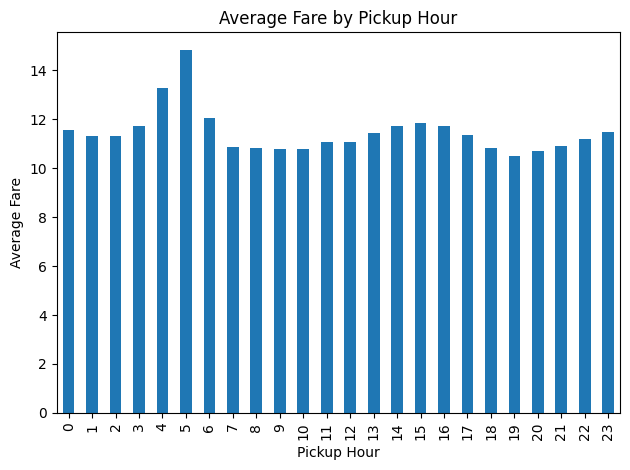

In [15]:
hourly = train_clean.groupby("pickup_hour")["fare_amount"].mean()
plt.figure()
hourly.plot(kind="bar")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Fare")
plt.title("Average Fare by Pickup Hour")
plt.tight_layout()
plt.show()

5 and 6 clock have the most highest average among 24 hours. (travel to airport, work, night service fee...)

<Figure size 640x480 with 0 Axes>

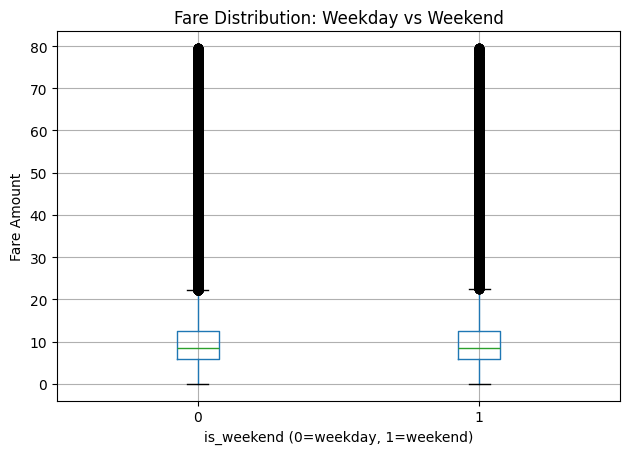

In [16]:
plt.figure()
train_clean.boxplot(column="fare_amount", by="is_weekend")
plt.suptitle("")
plt.title("Fare Distribution: Weekday vs Weekend")
plt.xlabel("is_weekend (0=weekday, 1=weekend)")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()

Fare distribution shows two similar bar, which means there's no diff between weekday and weekends.

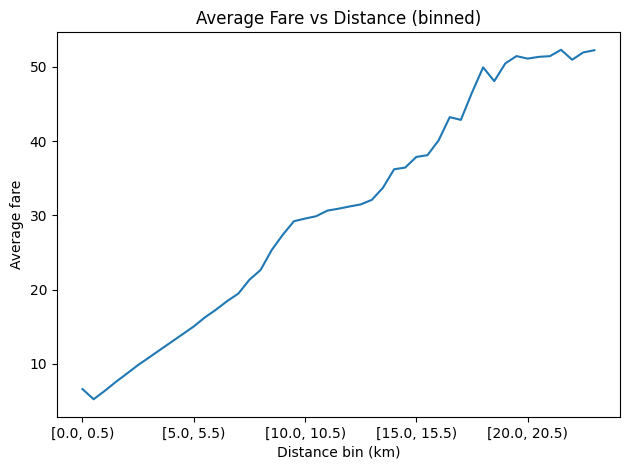

In [17]:
df["dist_bin"] = pd.cut(df["haversine_km"], bins=np.arange(0, 25.5, 0.5), right=False)
bin_mean = df.groupby("dist_bin")["fare_amount"].mean()

plt.figure()
bin_mean.plot()
plt.xlabel("Distance bin (km)")
plt.ylabel("Average fare")
plt.title("Average Fare vs Distance (binned)")
plt.tight_layout()
plt.show()

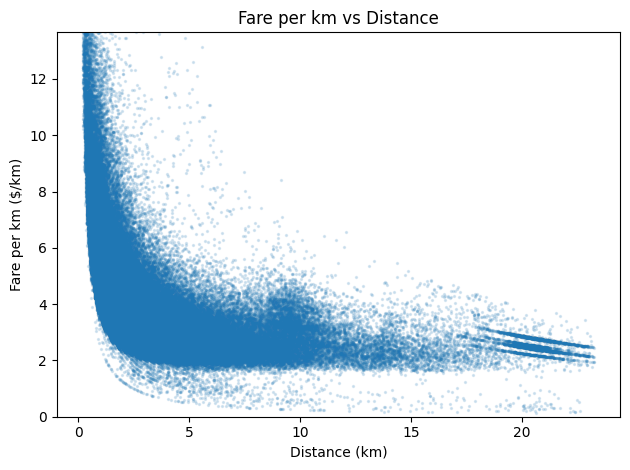

In [18]:
df2 = df[df["haversine_km"] > 0.2].copy() 
df2["fare_per_km"] = df2["fare_amount"] / df2["haversine_km"]

plt.figure()
plt.scatter(df2["haversine_km"], df2["fare_per_km"], s=2, alpha=0.15)
plt.xlabel("Distance (km)")
plt.ylabel("Fare per km ($/km)")
plt.title("Fare per km vs Distance")
plt.ylim(0, np.percentile(df2["fare_per_km"], 99)) 
plt.tight_layout()
plt.show()

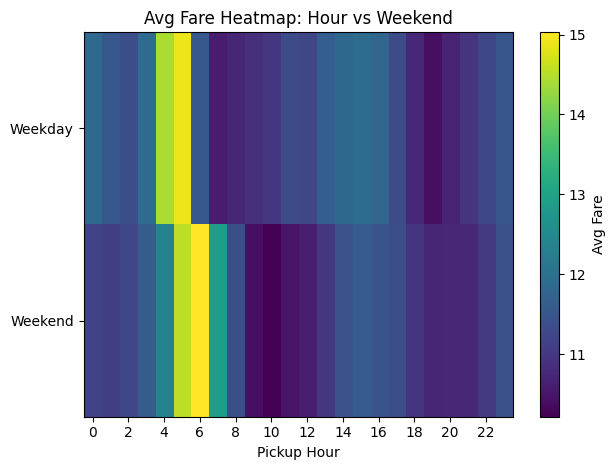

In [19]:
pivot = train_clean.groupby(["is_weekend", "pickup_hour"])["fare_amount"].mean().unstack(0)

plt.figure()
plt.imshow(pivot.T, aspect="auto")
plt.yticks([0,1], ["Weekday", "Weekend"])
plt.xticks(range(0,24,2), range(0,24,2))
plt.colorbar(label="Avg Fare")
plt.xlabel("Pickup Hour")
plt.title("Avg Fare Heatmap: Hour vs Weekend")
plt.tight_layout()
plt.show()

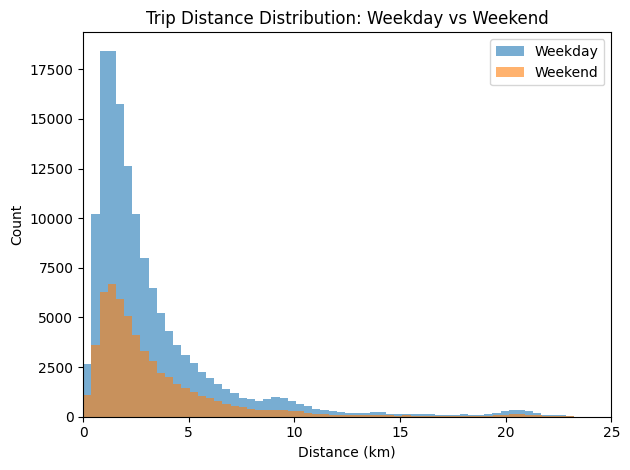

In [20]:
plt.figure()
plt.hist(df[df["is_weekend"]==0]["haversine_km"], bins=60, alpha=0.6, label="Weekday")
plt.hist(df[df["is_weekend"]==1]["haversine_km"], bins=60, alpha=0.6, label="Weekend")
plt.xlim(0, 25)
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.title("Trip Distance Distribution: Weekday vs Weekend")
plt.legend()
plt.tight_layout()
plt.show()

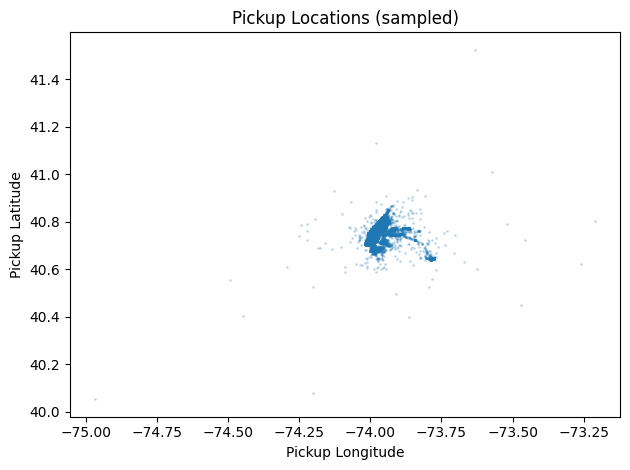

In [21]:
df_geo = df.sample(60_000, random_state=42)
plt.figure()
plt.scatter(df_geo["pickup_longitude"], df_geo["pickup_latitude"], s=1, alpha=0.2)
plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")
plt.title("Pickup Locations (sampled)")
plt.tight_layout()
plt.show()

In [22]:
### 3D Hexagon Layer with PyDeck -- Pickup locations aggregated into 3D hexagonal bins

geo = train_clean[["pickup_longitude", "pickup_latitude"]].dropna().sample(
    200_000, random_state=42
).rename(columns={"pickup_longitude":"lon", "pickup_latitude":"lat"})

view_state = pdk.ViewState(
    latitude=40.7580, longitude=-73.9855,
    zoom=10.5, pitch=50, bearing=-10
)

hex_layer = pdk.Layer(
    "HexagonLayer",
    data=geo,
    get_position='[lon, lat]',
    radius=120,
    elevation_scale=25,
    elevation_range=[0, 3000],
    extruded=True,
    coverage=1,
    pickable=True
)

MAP_STYLE = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"

deck = pdk.Deck(
    layers=[hex_layer],
    initial_view_state=view_state,
    map_style=MAP_STYLE,
    tooltip={"text": "Count: {points}"},
    description = "Pickup Density Legend"
)

deck.to_html("nyc_pickup_3d_hex.html", open_browser=False)
print("Saved: nyc_pickup_3d_hex.html")

TypeError: vars() argument must have __dict__ attribute

In [ ]:
### 3D Hexagon Layer with PyDeck -- dropoff locations aggregated into 3D hexagonal bins
geo_drop = train_clean[["dropoff_longitude", "dropoff_latitude"]].dropna().sample(
    200_000, random_state=42
).rename(columns={"dropoff_longitude": "lon", "dropoff_latitude": "lat"})

view_state = pdk.ViewState(
    latitude=40.7580, longitude=-73.9855,
    zoom=10.5, pitch=50, bearing=-10
)

hex_layer = pdk.Layer(
    "HexagonLayer",
    data=geo_drop,
    get_position='[lon, lat]',
    radius=120, 
    elevation_scale=25, 
    elevation_range=[0, 3000],
    extruded=True,
    coverage=1,
    pickable=True
)

MAP_STYLE = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"

deck = pdk.Deck(
    layers=[hex_layer],
    initial_view_state=view_state,
    map_style=MAP_STYLE,
    tooltip={"text": "Dropoff density (3D hex bins)"},
    description = "Dropoff Density Legend"
)

deck.to_html("nyc_dropoff_3d_hex.html", open_browser=False)
print("Saved: nyc_dropoff_3d_hex.html")

Saved: nyc_dropoff_3d_hex.html


In [23]:
### nyc_3d_count_color_fare
df = train_clean.sample(300_000, random_state=42).copy()
df = df[df["haversine_km"] > 0.3].copy()
df["fare_per_km"] = df["fare_amount"] / df["haversine_km"]

df = df[df["is_night"]==1]

GRID = 0.01
df["lat_bin"] = (df["pickup_latitude"] / GRID).round() * GRID
df["lon_bin"] = (df["pickup_longitude"] / GRID).round() * GRID

g = (df.groupby(["lat_bin","lon_bin"])
       .agg(
           trip_count=("fare_amount","size"),
           avg_fare=("fare_amount","mean"),
           avg_fare_per_km=("fare_per_km","mean")
       )
       .reset_index())

fare_min, fare_max = g["avg_fare"].quantile([0.05,0.95]).tolist()
g["fare_norm"] = ((g["avg_fare"]-fare_min)/(fare_max-fare_min)).clip(0,1)

g["color_r"] = (255 * g["fare_norm"]).astype(int)
g["color_g"] = (80  * (1-g["fare_norm"])).astype(int)
g["color_b"] = (160 * (1-g["fare_norm"])).astype(int)

layer = pdk.Layer(
    "ColumnLayer",
    data=g,
    get_position='[lon_bin, lat_bin]',
    get_elevation="trip_count",
    elevation_scale=2,
    radius=120,
    get_fill_color='[color_r, color_g, color_b, 160]',
    pickable=True,
    extruded=True,
)

view_state = pdk.ViewState(latitude=40.7580, longitude=-73.9855, zoom=10.5, pitch=50)
MAP_STYLE = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    map_style=MAP_STYLE,
    tooltip={"text": "count: {trip_count}\navg fare: {avg_fare}\navg $/km: {avg_fare_per_km}"},
    description = "3D Column: Height=count, Color=avg fare"
)

deck.to_html("nyc_3d_count_color_fare.html", open_browser=False)
print("Saved: nyc_3d_count_color_fare.html")

TypeError: vars() argument must have __dict__ attribute

In [24]:
df = train_clean.sample(300_000, random_state=42).copy()
GRID = 0.01
df["lat_bin"] = (df["pickup_latitude"] / GRID).round() * GRID
df["lon_bin"] = (df["pickup_longitude"] / GRID).round() * GRID

# count / avg_fare / avg_fare_per_km
df["fare_per_km"] = df["fare_amount"] / df["haversine_km"].clip(lower=0.3)

agg = (
    df.groupby(["lat_bin","lon_bin","pickup_hour","is_weekend","is_night"])
      .agg(
          trip_count=("fare_amount","size"),
          avg_fare=("fare_amount","mean"),
          avg_fare_per_km=("fare_per_km","mean"),
          avg_dist=("haversine_km","mean"),
      )
      .reset_index()
)

agg.head(), agg.shape

(   lat_bin  lon_bin  pickup_hour  is_weekend  is_night  trip_count  avg_fare  avg_fare_per_km  avg_dist
 0    40.05   -74.97            0           1         1           1      10.1         6.928344  1.457780
 1    40.05   -73.02           10           0         0           1       6.5         2.569416  2.529757
 2    40.06   -73.53            9           0         0           1       3.7         1.034315  3.577246
 3    40.08   -74.20           20           1         0           1       3.7         7.110992  0.520321
 4    40.17   -73.64           12           1         0           1       4.5        12.937009  0.347839,
 (7385, 9))

phase 3:

In [25]:
features = ["passenger_count",
    "pickup_hour", "pickup_dow", "pickup_month",
    "is_weekend", "is_rush_hour", "is_night",
    "haversine_km"]

X = train_clean[features].copy()
y = train_clean["fare_amount"].copy()

mask = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
X = X.loc[mask]
y = y.loc[mask]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# --- Model 1: Ridge---
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0, solver="auto"))
])
with warnings.catch_warnings():
    # By checking Ridge's coef_ after fitting, we know it has numerical issues (inf/nan) likely due to the nature of the data and regularization path.
    # So we choose to ingore the warnings about numerical issues during fitting, but still check the coefficients after to confirm.
    warnings.filterwarnings("ignore", message=".*divide by zero encountered in matmul.*")
    warnings.filterwarnings("ignore", message=".*overflow encountered in matmul.*")
    warnings.filterwarnings("ignore", message=".*invalid value encountered in matmul.*")
    ridge.fit(X_train, y_train)
    pred_ridge = ridge.predict(X_val)
    print("Ridge RMSE:", rmse(y_val, pred_ridge))

# --- Model 2: RandomForest---
rf = RandomForestRegressor(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
print("RF RMSE:", rmse(y_val, pred_rf))


Ridge RMSE: 4.118745497943366
RF RMSE: 3.9189549953793446


In [26]:
# Chekc the Ridge model's input and coefficients for numerical issues, since Ridge can be sensitive to feature scaling and regularization strength, which may lead to inf/nan coefficients if not handled properly. 
# This is a common issue when using linear models on real-world data with varying scales and distributions. 
# By checking the finiteness and magnitude of the inputs and coefficients, we can confirm if the model has encountered numerical instability during fitting.
Xt = X_train.to_numpy(dtype=np.float64)
Xv = X_val.to_numpy(dtype=np.float64)

print("X_train finite:", np.isfinite(Xt).all())
print("X_val finite:", np.isfinite(Xv).all())
print("X_train abs max:", np.nanmax(np.abs(Xt)))
print("X_val abs max:", np.nanmax(np.abs(Xv)))

model = ridge.named_steps["model"] if hasattr(ridge, "named_steps") else ridge
coef = model.coef_
print("coef finite:", np.isfinite(coef).all(), "coef abs max:", np.nanmax(np.abs(coef)))

X_train finite: True
X_val finite: True
X_train abs max: 23.257657179921633
X_val abs max: 23.255994447718983
coef finite: True coef abs max: 8.101254459153209


Ridge RMSE = 4.118744, RF RMSE = 3.918873

RF is smaller than Ridge. The bias between excepted fee and real fee is nearly 4 dollars. 

In [27]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("RF Feature Importance:")
print(imp)

RF Feature Importance:
haversine_km       0.981550
pickup_hour        0.006988
is_night           0.003996
pickup_month       0.002726
pickup_dow         0.002500
passenger_count    0.001198
is_weekend         0.000742
is_rush_hour       0.000301
dtype: float64


In [15]:
# test if it's overfitting or underfitting by comparing train vs val RMSE and their ratio (gap ratio)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Ridge RMSE: 4.11
ridge.fit(X_train, y_train)
pred_train_ridge = ridge.predict(X_train)
pred_val_ridge = ridge.predict(X_val)

rmse_train_ridge = rmse(y_train, pred_train_ridge)
rmse_val_ridge = rmse(y_val, pred_val_ridge)

print("Ridge RMSE train:", rmse_train_ridge)
print("Ridge RMSE val:", rmse_val_ridge)
print("Ridge gap ratio:", rmse_val_ridge / rmse_train_ridge)

# RandomForest RMSE: 3.918
rf.fit(X_train, y_train)
pred_train_rf = rf.predict(X_train)
pred_val_rf = rf.predict(X_val)

rmse_train_rf = rmse(y_train, pred_train_rf)
rmse_val_rf = rmse(y_val, pred_val_rf)

print("RF RMSE train:", rmse_train_rf)
print("RF RMSE val:", rmse_val_rf)
print("RF gap ratio:", rmse_val_rf / rmse_train_rf)

NameError: name 'ridge' is not defined

From the result, we find out that ridge is underfitting. RF is better.

and because we have Box-cox (which is in my R code) shows that lembda is near 0 ,therefore log-like is better, so I'm going to do log1p(fare)

In [29]:
# log-like on fare amount to see if it helps Ridge and RF. 
# Because I did Boxcox in my R code, and lembda was around 0, which is close to log transform.

# ---- 1) log-transform target ----
y_train_log = np.log1p(y_train.to_numpy())
y_val_log   = np.log1p(y_val.to_numpy())

# defined rmse() before, now define a helper to pirnt both RMSE and MAE for regression evaluation.
def eval_regression(name, y_true, y_pred):
    print(f"{name} RMSE: {rmse(y_true, y_pred):.4f}")
    print(f"{name} MAE : {mean_absolute_error(y_true, y_pred):.4f}")

# ---- Model A: Ridge on log(y) ----
ridge_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

ridge_log.fit(X_train, y_train_log)

pred_train_log = ridge_log.predict(X_train)
pred_val_log   = ridge_log.predict(X_val)

# inverse transform back to dollars
pred_train = np.expm1(pred_train_log)
pred_val   = np.expm1(pred_val_log)

print("=== Ridge on log1p(y) (evaluated in $) ===")
eval_regression("Ridge_log train", y_train.to_numpy(), pred_train)
eval_regression("Ridge_log val", y_val.to_numpy(), pred_val)

# ---- Model B: RandomForest on log(y) ----
rf_log = RandomForestRegressor(
    n_estimators=400,
    max_depth=16,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_log.fit(X_train, y_train_log)

pred_train_log = rf_log.predict(X_train)
pred_val_log   = rf_log.predict(X_val)

pred_train = np.expm1(pred_train_log)
pred_val   = np.expm1(pred_val_log)

print("\n=== RandomForest on log1p(y) (evaluated in $) ===")
eval_regression("RF_log train", y_train.to_numpy(), pred_train)
eval_regression("RF_log val", y_val.to_numpy(), pred_val)

=== Ridge on log1p(y) (evaluated in $) ===
Ridge_log train RMSE: 7.4327
Ridge_log train MAE : 3.2104
Ridge_log val RMSE: 7.4405
Ridge_log val MAE : 3.2044

=== RandomForest on log1p(y) (evaluated in $) ===
RF_log train RMSE: 3.7230
RF_log train MAE : 1.9908
RF_log val RMSE: 3.9800
RF_log val MAE : 2.1176


Ridge_log is confused, it should be better than before. but now it's increase to 7.4. We need to figure out why and fix it. 

In [30]:
y_val_arr = y_val.to_numpy()

pred_val_log = ridge_log.predict(X_val)
pred_val = np.expm1(pred_val_log)

print("pred_val min/max:", pred_val.min(), pred_val.max())
print("y_val   min/max:", y_val_arr.min(), y_val_arr.max())

neg_rate = np.mean(pred_val < 0)
print("negative prediction rate:", neg_rate)

abs_err = np.abs(y_val_arr - pred_val)
idx = np.argsort(-abs_err)[:10]
print("top10 abs err:", abs_err[idx])
print("top10 y_true:", y_val_arr[idx])
print("top10 y_pred:", pred_val[idx])

pred_val min/max: 5.306987784383196 137.9606676957286
y_val   min/max: 0.01 79.5
negative prediction rate: 0.0
top10 abs err: [118.4968935  117.57919478 116.55928061 114.76900967 114.5234453
 113.22598009 111.73490552 110.87194987 110.56183627 107.79428517]
top10 y_true: [ 4.5   3.7   4.5   3.7   7.83  4.1  12.   18.    6.5  13.7 ]
top10 y_pred: [122.9968935  121.27919478 121.05928061 118.46900967 122.3534453
 117.32598009 123.73490552 128.87194987 117.06183627 121.49428517]


y_true and y_pred is wired. the abs err is huge. 

In [31]:
def report(name, y_true, y_pred):
    print(f"{name} RMSE: {rmse(y_true, y_pred):.4f}")
    print(f"{name} MAE : {mean_absolute_error(y_true, y_pred):.4f}")

candidates = [200, 400, 800, 1200, 2000, 4000]
best = None

for n in candidates:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist"
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    score = rmse(y_val.to_numpy(), pred)
    print("n_estimators=", n, "val RMSE=", score)
    if best is None or score < best[0]:
        best = (score, n)

print("Best:", best)

n_estimators= 200 val RMSE= 3.9142359780995295
n_estimators= 400 val RMSE= 3.913026248429103
n_estimators= 800 val RMSE= 3.918088078763317
n_estimators= 1200 val RMSE= 3.921891312268051
n_estimators= 2000 val RMSE= 3.9298798719135295
n_estimators= 4000 val RMSE= 3.9452608545353773
Best: (np.float64(3.913026248429103), 400)


n = 400 and RMSE = 3.913026 which is the best. More data would make it overfit. Now we choose ~400

In [32]:
xgb_best = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    tree_method="hist"
)

xgb_best.fit(X_train, y_train)

pred_train = xgb_best.predict(X_train)
pred_val   = xgb_best.predict(X_val)

print("XGB train RMSE:", rmse(y_train.to_numpy(), pred_train))
print("XGB val   RMSE:", rmse(y_val.to_numpy(), pred_val))
print("XGB train MAE :", mean_absolute_error(y_train.to_numpy(), pred_train))
print("XGB val   MAE :", mean_absolute_error(y_val.to_numpy(), pred_val))
print("gap ratio:", rmse(y_val.to_numpy(), pred_val) / rmse(y_train.to_numpy(), pred_train))

# Check feature importance from the best XGB model to see which features are most influential in predicting taxi fares.
importance = xgb_best.feature_importances_
imp_df = pd.DataFrame({"feature": X_train.columns, "importance": importance})
imp_df = imp_df.sort_values("importance", ascending=False)
print(imp_df.head(10))

XGB train RMSE: 3.8943863738530498
XGB val   RMSE: 3.913026248429103
XGB train MAE : 2.1531975479442047
XGB val   MAE : 2.157599283196763
gap ratio: 1.004786344442144
           feature  importance
7     haversine_km    0.960671
6         is_night    0.021830
1      pickup_hour    0.006220
4       is_weekend    0.003060
2       pickup_dow    0.002455
3     pickup_month    0.002199
0  passenger_count    0.001904
5     is_rush_hour    0.001661


gap ratio is good and RMSE is good. the output also shows the importance of the feature. and I want to know is passenger_count and is_rush_hour neccesary for the model. Since in my opinion, the passenger count probably not impact the fare amount. So, now I want to test it. 

In [33]:
def run_xgb(X_train, y_train, X_val, y_val, feat_cols, name):
    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist"
    )
    model.fit(X_train[feat_cols], y_train)
    pred = model.predict(X_val[feat_cols])
    return {
        "model": name,
        "n_features": len(feat_cols),
        "val_RMSE": rmse(y_val.to_numpy(), pred),
        "val_MAE": mean_absolute_error(y_val.to_numpy(), pred)
    }

all_feats = ["passenger_count","pickup_hour","pickup_dow","pickup_month",
             "is_weekend","is_rush_hour","is_night","haversine_km"]

variants = {
    "All features": all_feats,
    "Drop passenger_count": [f for f in all_feats if f != "passenger_count"],
    "Drop is_rush_hour": [f for f in all_feats if f != "is_rush_hour"],
    "Drop passenger + rush": [f for f in all_feats if f not in ["passenger_count","is_rush_hour"]],
    "Only distance + time basics": ["haversine_km","pickup_hour","pickup_dow","pickup_month","is_weekend","is_night"],
}

results = []
for name, feats in variants.items():
    results.append(run_xgb(X_train, y_train, X_val, y_val, feats, name))

df = pd.DataFrame(results).sort_values("val_RMSE")
df

,model,n_features,val_RMSE,val_MAE
2,Drop is_rush_hour,7,3.912962,2.158011
0,All features,8,3.913026,2.157599
4,Only distance + time basics,6,3.916062,2.160520
3,Drop passenger + rush,6,3.916769,2.160770
1,Drop passenger_count,7,3.917270,2.160792


Now we can found out, passenger is important, in small datasets. but is_rush_hour is not. Since is_hour_rush and pickup_hour is highly recommended, so we need to delete it.

***Now we have the winner, ["passenger_count","pickup_hour","pickup_dow","pickup_month","is_weekend","is_night","haversine_km"], model = XGBoost*** 

In [34]:
# Based on the feature importance and ablation results, we can identify a subset of features that provide a good balance of predictive power and simplicity.
final_features = ["passenger_count","pickup_hour","pickup_dow","pickup_month","is_weekend","is_night","haversine_km"]

I need to use Lat_min and max, Lon_min and max to get a real distance, not direct distance between two point. 

In [29]:
# same as nyc bounds
LAT_MIN, LAT_MAX = 40.5, 41.0
LON_MIN, LON_MAX = -74.3, -73.7

def add_grid(df, lat_col, lon_col, n_lat=60, n_lon=60, prefix=""):
    out = df.copy()

    lat = out[lat_col].clip(LAT_MIN, LAT_MAX)
    lon = out[lon_col].clip(LON_MIN, LON_MAX)

    dlat = (LAT_MAX - LAT_MIN) / n_lat
    dlon = (LON_MAX - LON_MIN) / n_lon

    out[f"{prefix}grid_i"] = ((lat - LAT_MIN) / dlat).astype(int).clip(0, n_lat-1)
    out[f"{prefix}grid_j"] = ((lon - LON_MIN) / dlon).astype(int).clip(0, n_lon-1)

    out[f"{prefix}cell_id"] = out[f"{prefix}grid_i"] * n_lon + out[f"{prefix}grid_j"]
    return out

df = train_clean.copy()

df = add_grid(df, "pickup_latitude",  "pickup_longitude",  n_lat=9, n_lon=9, prefix="pu_")
df = add_grid(df, "dropoff_latitude", "dropoff_longitude", n_lat=9, n_lon=9, prefix="do_")

pu_counts = df["pu_cell_id"].value_counts()
print("pickup non-empty cells:", (pu_counts>0).sum())
print("pickup median per cell:", pu_counts.median())
print("pickup <20 samples ratio:", (pu_counts<20).mean())

pickup non-empty cells: 81
pickup median per cell: 35.0
pickup <20 samples ratio: 0.3333333333333333


In [30]:
# 先切分（确保统计量只用 train 计算）
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

def add_cell_stats(train_df, other_df, cell_col, target_col="fare_amount", prefix=""):
    stats = train_df.groupby(cell_col)[target_col].agg(["mean", "count"]).rename(
        columns={"mean": f"{prefix}mean", "count": f"{prefix}count"}
    )
    # merge
    other_df = other_df.join(stats, on=cell_col)
    return other_df, stats

# 给 train / val 都加 pickup cell stats
train_df, pu_stats = add_cell_stats(train_df, train_df, "pu_cell_id", prefix="pu_fare_")
val_df  = val_df.join(pu_stats, on="pu_cell_id")

# 给 train / val 都加 dropoff cell stats
train_df, do_stats = add_cell_stats(train_df, train_df, "do_cell_id", prefix="do_fare_")
val_df  = val_df.join(do_stats, on="do_cell_id")

# 缺失（val 中出现 train 没见过的 cell）补默认值
for c in ["pu_fare_mean","pu_fare_count","do_fare_mean","do_fare_count"]:
    train_df[c] = train_df[c].fillna(train_df["fare_amount"].mean() if "mean" in c else 0)
    val_df[c]   = val_df[c].fillna(train_df["fare_amount"].mean() if "mean" in c else 0)

In [12]:
train_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_dow,pickup_month,is_weekend,is_rush_hour,is_night,haversine_km,manhattan_km,distance_ratio_manhattan_haversine,trip_bearing,bearing_sin,bearing_cos,pickup_to_jfk_km,dropoff_to_jfk_km,pickup_to_lga_km,dropoff_to_lga_km,pickup_to_manhattan_km,dropoff_to_manhattan_km,is_jfk_trip,is_lga_trip,pickup_in_manhattan_core,dropoff_in_manhattan_core,dist_x_jfk,dist_x_lga,is_short_trip,is_long_trip,dist_x_long_trip,dist_x_rush,dist_x_night,hour_sin,hour_cos,pu_grid_i,pu_grid_j,pu_cell_id,do_grid_i,do_grid_j,do_cell_id,pu_fare_mean,pu_fare_count,do_fare_mean,do_fare_count
1732940,2011-11-30 17:13:50.0000002,4.9,2011-11-30 17:13:50+00:00,-73.990235,40.734430,-73.999958,40.734632,1,17,2,11,0,1,0,0.819538,0.841691,1.027030,-88.426306,-0.999623,0.027463,20.667861,21.392145,10.869928,11.603892,2.651045,2.869696,0,0,1,1,0.0,0.0,1,0,0.0,0.841691,0.0,-0.965926,-0.258819,4,4,40,4,4,40,10.051383,970265,9.457557,901170
1734871,2012-04-16 19:00:00.00000064,6.9,2012-04-16 19:00:00+00:00,-73.994677,40.765987,-73.977672,40.784067,1,19,0,4,0,1,0,2.468221,3.442127,1.394578,35.454950,0.580063,0.814572,22.924412,23.129096,10.234429,8.765356,1.177341,2.972533,0,0,1,1,0.0,0.0,0,0,0.0,3.442127,0.0,-0.965926,0.258819,4,4,40,5,4,49,10.051383,970265,9.645590,83773
528350,2009-04-09 13:20:15.0000004,12.5,2009-04-09 13:20:15+00:00,-73.976486,40.759955,-73.991751,40.729905,1,13,3,4,0,0,0,3.580329,4.627680,1.292529,-158.945185,-0.359261,-0.933237,21.301791,20.532989,8.834037,11.210893,0.789722,3.168096,0,0,1,1,0.0,0.0,0,0,0.0,0.000000,0.0,-0.258819,-0.965926,4,4,40,4,4,40,10.051383,970265,9.457557,901170
280431,2012-08-22 07:56:24.0000003,11.7,2012-08-22 07:56:24+00:00,-73.949029,40.771624,-73.991909,40.737828,1,7,2,8,0,1,0,5.212249,7.370704,1.414112,-136.121707,-0.693129,-0.720814,20.435040,20.980497,6.345119,10.839983,3.424810,2.307085,0,0,1,1,0.0,0.0,0,0,0.0,7.370704,0.0,0.965926,-0.258819,4,5,41,4,4,40,9.924466,174426,9.457557,901170
1402370,2013-05-28 07:52:00.0000003,5.0,2013-05-28 07:52:00+00:00,-73.954395,40.769865,-73.946662,40.774145,2,7,1,5,0,1,0,0.806564,1.127085,1.397391,53.836814,0.807340,0.590087,20.620490,20.495773,6.814927,6.126171,2.933124,3.731107,0,0,1,1,0.0,0.0,0,0,0.0,1.127085,0.0,0.965926,-0.258819,4,5,41,4,5,41,9.924466,174426,10.131841,179140


In [31]:
base_features = [
    "passenger_count",
    "pickup_hour", "pickup_dow", "pickup_month",
    "is_weekend", "is_night",
    "haversine_km"]

grid_features = ["pu_grid_i","pu_grid_j","do_grid_i","do_grid_j"]

manhattan_features = ["manhattan_km", "distance_ratio_manhattan_haversine"]

bearing_features = ["trip_bearing", "bearing_sin", "bearing_cos"]

def train_eval(features, name):
    X_tr = train_df[features]
    y_tr = train_df["fare_amount"]
    X_va = val_df[features]
    y_va = val_df["fare_amount"]

    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist"
    )
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    print(f"{name} RMSE: {rmse(y_va.to_numpy(), pred):.4f}")
    print(f"{name} MAE : {mean_absolute_error(y_va.to_numpy(), pred):.4f}")
    return model

print("=== Baseline ===")
_ = train_eval(base_features, "XGB_base")

print("\n=== With Grid + Cell Stats ===")
_ = train_eval(base_features + grid_features, "XGB_grid")

print("\n=== With Grid + Cell Stats + Manhattan ===")
_ = train_eval(base_features + grid_features + manhattan_features, "XGB_grid_manhattan")

=== Baseline ===
XGB_base RMSE: 3.9130
XGB_base MAE : 2.1580

=== With Grid + Cell Stats ===
XGB_grid RMSE: 3.5901
XGB_grid MAE : 2.0016

=== With Grid + Cell Stats + Manhattan ===
XGB_grid_manhattan RMSE: 3.5447
XGB_grid_manhattan MAE : 1.9581


In [32]:
print("\n=== With Grid + Cell Stats + Manhattan + Bearing ===")
_ = train_eval(base_features + grid_features + manhattan_features + bearing_features, "XGB_grid_manhattan_bearing")


=== With Grid + Cell Stats + Manhattan + Bearing ===
XGB_grid_manhattan_bearing RMSE: 3.4841
XGB_grid_manhattan_bearing MAE : 1.8829


In [33]:
poi_features = ["pickup_to_jfk_km",
    "dropoff_to_jfk_km",
    "pickup_to_lga_km",
    "dropoff_to_lga_km",
    "pickup_to_manhattan_km",
    "dropoff_to_manhattan_km",

    "is_jfk_trip",
    "is_lga_trip",
]

print("\n=== With Grid + Cell Stats + Manhattan + Bearing + POI ===")
_ = train_eval(base_features + grid_features + manhattan_features + bearing_features + poi_features, "XGB_grid_manhattan_bearing_poi")


=== With Grid + Cell Stats + Manhattan + Bearing + POI ===
XGB_grid_manhattan_bearing_poi RMSE: 3.3744
XGB_grid_manhattan_bearing_poi MAE : 1.8177


In [34]:
interaction_features = ["dist_x_jfk", "dist_x_lga", "dist_x_rush", "dist_x_night"]

print("\n=== With Grid + Cell Stats + Manhattan + Bearing + POI + Interactions ===")
_ = train_eval(base_features + grid_features + manhattan_features + bearing_features + poi_features + interaction_features, "XGB_grid_manhattan_bearing_poi_interaction")


=== With Grid + Cell Stats + Manhattan + Bearing + POI + Interactions ===
XGB_grid_manhattan_bearing_poi_interaction RMSE: 3.3706
XGB_grid_manhattan_bearing_poi_interaction MAE : 1.8180


In [35]:
hours_features = ["hour_sin", "hour_cos"]

base_features_drop_hours = [
    "passenger_count",
    "pickup_hour", "pickup_dow", "pickup_month",
    "is_weekend", "is_night",
    "haversine_km"]

print("\n=== With Grid + Cell Stats + Manhattan + Bearing + POI + Interactions + Hour sin/cos, but drop original hour features ===")
_ = train_eval(base_features_drop_hours + grid_features + manhattan_features + bearing_features + poi_features + interaction_features + hours_features, "XGB_grid_manhattan_bearing_poi_interaction_hours")


=== With Grid + Cell Stats + Manhattan + Bearing + POI + Interactions + Hour sin/cos, but drop original hour features ===
XGB_grid_manhattan_bearing_poi_interaction_hours RMSE: 3.3732
XGB_grid_manhattan_bearing_poi_interaction_hours MAE : 1.8175


In [36]:
core_features = ["pickup_in_manhattan_core", "dropoff_in_manhattan_core"]

print("\n=== With Grid + Cell Stats + Manhattan + Bearing + POI + Interactions + Core ===")
_ = train_eval(base_features + grid_features + manhattan_features + bearing_features + poi_features + interaction_features + core_features, "XGB_grid_manhattan_bearing_poi_interaction_core")


=== With Grid + Cell Stats + Manhattan + Bearing + POI + Interactions + Core ===
XGB_grid_manhattan_bearing_poi_interaction_core RMSE: 3.3761
XGB_grid_manhattan_bearing_poi_interaction_core MAE : 1.8186


In [39]:
trip_length_features = ["is_long_trip", "dist_x_long_trip"]

print("\n=== With Grid + Manhattan + Bearing + POI + Interactions + Long-trip ===")
_ = train_eval(
    base_features_drop_hours + grid_features + manhattan_features + bearing_features + poi_features + interaction_features + trip_length_features + core_features + hours_features,
    "XGB_grid_manhattan_bearing_poi_interaction_longtrip"
)


=== With Grid + Manhattan + Bearing + POI + Interactions + Long-trip ===
XGB_grid_manhattan_bearing_poi_interaction_longtrip RMSE: 3.3726
XGB_grid_manhattan_bearing_poi_interaction_longtrip MAE : 1.8174


In [38]:
def run_variant(train_df, val_df, feats, name):
    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist"
    )
    model.fit(train_df[feats], train_df["fare_amount"])
    pred = model.predict(val_df[feats])
    return {
        "variant": name,
        "n_features": len(feats),
        "val_RMSE": rmse(val_df["fare_amount"].to_numpy(), pred),
        "val_MAE": mean_absolute_error(val_df["fare_amount"].to_numpy(), pred)
    }

base_feats = [
    "passenger_count","pickup_hour","pickup_dow","pickup_month",
    "is_weekend","is_night","haversine_km"
]
grid_feats = ["pu_grid_i","pu_grid_j","do_grid_i","do_grid_j"]

manhattan_feats = ["manhattan_km", "distance_ratio_manhattan_haversine"]

FULL = base_feats + grid_feats + manhattan_feats + bearing_features + poi_features

variants = {
    "FULL (final candidate)": FULL,
    "Drop passenger_count": [f for f in FULL if f != "passenger_count"],
    "Drop pickup_month": [f for f in FULL if f != "pickup_month"],
    "Drop dow + weekend": [f for f in FULL if f not in ["pickup_dow","is_weekend"]],
    "Drop is_night": [f for f in FULL if f != "is_night"],
    "Drop pickup_hour": [f for f in FULL if f != "pickup_hour"],
    "Drop grid features": [f for f in FULL if f not in grid_feats],
    "Drop manhattan features": [f for f in FULL if f not in manhattan_feats],
    "Drop bearing features": [f for f in FULL if f not in bearing_features],
    "Drop POI features": [f for f in FULL if f not in poi_features],
    "Drop pickup_to_jfk_km": [f for f in FULL if f != "pickup_to_jfk_km"],
    "Drop dropoff_to_jfk_km": [f for f in FULL if f != "dropoff_to_jfk_km"]
}

results = [run_variant(train_df, val_df, feats, name) for name, feats in variants.items()]
pd.DataFrame(results).sort_values("val_RMSE")

,variant,n_features,val_RMSE,val_MAE
6,Drop grid features,20,3.372059,1.816573
0,FULL (final candidate),24,3.374433,1.817690
1,Drop passenger_count,23,3.374722,1.820206
4,Drop is_night,23,3.375508,1.818591
7,Drop manhattan features,22,3.376148,1.819786
10,Drop pickup_to_jfk_km,23,3.382471,1.822657
2,Drop pickup_month,23,3.384042,1.826214
8,Drop bearing features,21,3.385066,1.840102
3,Drop dow + weekend,22,3.390492,1.838230
11,Drop dropoff_to_jfk_km,23,3.392583,1.825494


We dont need to delete some variables this time. Perfect

In [156]:
# Need to do the same feature on RandomForest to see if the importance of the grid features is consistent across models, since different models can capture different patterns and interactions in the data.
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(train_df[FULL], train_df["fare_amount"])
pred = rf.predict(val_df[FULL])

print("RF_grid RMSE:", rmse(val_df["fare_amount"].to_numpy(), pred))
print("RF_grid MAE :", mean_absolute_error(val_df["fare_amount"].to_numpy(), pred))

RF_grid RMSE: 3.3810364479084756
RF_grid MAE : 1.8301258657870254


Now, need to add more features: like Manhatton Distance, angular, 

step() : import mlxtend, SequentialFeatureSelector

Manhattan Distance has already added into the table in front, check front

In [ ]:
train_clean[["haversine_km", "manhattan_km"]].describe()

np.float64(0.0)

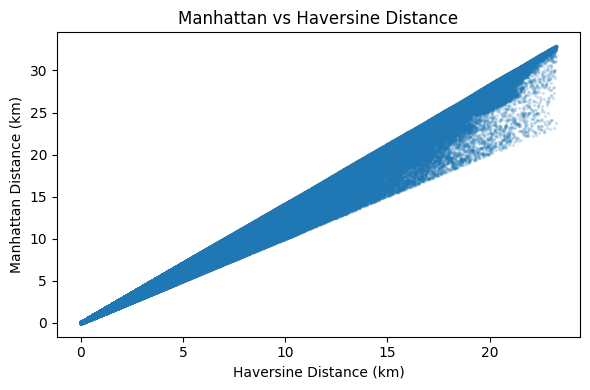

In [44]:
plt.figure(figsize=(6, 4))
plt.scatter(
    train_clean["haversine_km"],
    train_clean["manhattan_km"],
    s=2,
    alpha=0.15
)
plt.xlabel("Haversine Distance (km)")
plt.ylabel("Manhattan Distance (km)")
plt.title("Manhattan vs Haversine Distance")
plt.tight_layout()
plt.show()

In [46]:
(train_clean["manhattan_km"] < train_clean["haversine_km"]).mean()

np.float64(0.0)

In [155]:
# I want to see Ridge Model's coefficients to understand how it weights the features, especially since we observed numerical issues during fitting.
FULL = base_features_drop_hours + grid_features + manhattan_features + bearing_features + poi_features + interaction_features + hours_features + core_features

X = train_df[FULL].copy()
y = train_df["fare_amount"].copy()

mask = np.isfinite(X.to_numpy()).all(axis=1) & np.isfinite(y.to_numpy())
X = X.loc[mask]
y = y.loc[mask]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# --- Model 1: Ridge---
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0, solver="auto"))
])
with warnings.catch_warnings():
    # By checking Ridge's coef_ after fitting, we know it has numerical issues (inf/nan) likely due to the nature of the data and regularization path.
    # So we choose to ingore the warnings about numerical issues during fitting, but still check the coefficients after to confirm.
    warnings.filterwarnings("ignore", message=".*divide by zero encountered in matmul.*")
    warnings.filterwarnings("ignore", message=".*overflow encountered in matmul.*")
    warnings.filterwarnings("ignore", message=".*invalid value encountered in matmul.*")
    ridge.fit(X_train, y_train)
    pred_ridge = ridge.predict(X_val)
    print("Ridge RMSE:", rmse(y_val, pred_ridge))

Ridge RMSE: 3.9055629796349347
